<a href="https://colab.research.google.com/github/omar192501/Titanic_Passenger_Data_Analysis_and_Survival_Prediction_Using_Machine_Learning/blob/main/Titanic_Passenger_Data_Analysis_and_Survival_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

a. Import the necessary Python libraries and load the Titanic dataset from Seaborn.

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


b. Display the first five rows of the dataset and the last ten rows.

In [3]:
print(df.head())
print(df.tail(10))

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
881         0       3    male  33.0      0      0   7.8958        S   Third   
882         0       3  female  22.0      0      0  10.5167   

c. Display a summary of the dataset, including column types and missing values.

In [4]:
df.info()
print("\nMV:", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

MV: survived         0
pclass           0
sex              0
age            17

d. Handle missing values using at least three different ways.

In [18]:
df['age'] = df['age'].fillna(df['age'].mean())
df['fare'] = df['fare'].fillna(df['fare'].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck'])
display(df)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,0,22.000000,1,0,7.2500,2.0,3,man,True,Southampton,no,False
1,1,1,1,38.000000,1,0,71.2833,0.0,1,woman,False,Cherbourg,yes,False
2,1,3,1,26.000000,0,0,7.9250,2.0,3,woman,False,Southampton,yes,True
3,1,1,1,35.000000,1,0,53.1000,2.0,1,woman,False,Southampton,yes,False
4,0,3,0,35.000000,0,0,8.0500,2.0,3,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,13.0000,2.0,2,man,True,Southampton,no,True
887,1,1,1,19.000000,0,0,30.0000,2.0,1,woman,False,Southampton,yes,True
888,0,3,1,29.699118,1,2,23.4500,2.0,3,woman,False,Southampton,no,False
889,1,1,0,26.000000,0,0,30.0000,0.0,1,man,True,Cherbourg,yes,True


e. Convert categorical variables into numerical representations where applicable.

In [6]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['embarked'] = df['embarked'].map({'C':0, 'Q':1, 'S':2})
df['class']=df['class'].map({'First':1, 'Second':2, 'Third':3})
display(df)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,0,22.0,1,0,7.2500,2.0,3,man,True,NaN,Southampton,no,False
1,1,1,1,38.0,1,0,71.2833,0.0,1,woman,False,C,Cherbourg,yes,False
2,1,3,1,26.0,0,0,7.9250,2.0,3,woman,False,NaN,Southampton,yes,True
3,1,1,1,35.0,1,0,53.1000,2.0,1,woman,False,C,Southampton,yes,False
4,0,3,0,35.0,0,0,8.0500,2.0,3,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,2.0,2,man,True,NaN,Southampton,no,True
887,1,1,1,19.0,0,0,30.0000,2.0,1,woman,False,B,Southampton,yes,True
888,0,3,1,NaN,1,2,23.4500,2.0,3,woman,False,NaN,Southampton,no,False
889,1,1,0,26.0,0,0,30.0000,0.0,1,man,True,C,Cherbourg,yes,True


In [20]:
print(df[['pclass','sex','age','fare','embarked']].isnull().sum())

pclass      0
sex         0
age         0
fare        0
embarked    0
dtype: int64


f. Perform feature selection to identify relevant columns for analysis and machine learning.

In [7]:
SF= df[['survived','pclass','sex','age','fare','embarked']]
print(SF.head())

   survived  pclass  sex   age     fare  embarked
0         0       3    0  22.0   7.2500       2.0
1         1       1    1  38.0  71.2833       0.0
2         1       3    1  26.0   7.9250       2.0
3         1       1    1  35.0  53.1000       2.0
4         0       3    0  35.0   8.0500       2.0


g. Visualize the distribution of passengers’ genders (sex)

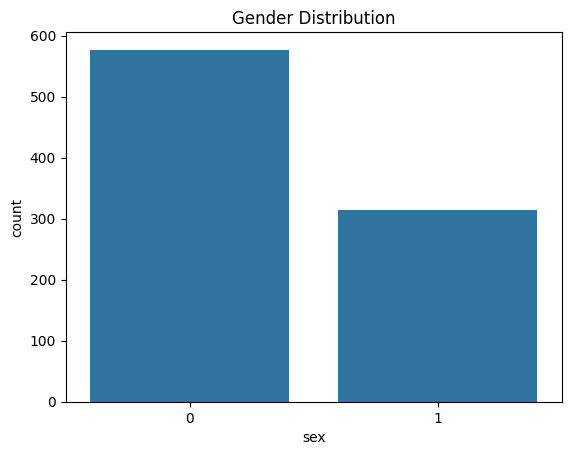

In [8]:
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

h. Show the distribution of passengers’ ages (age).

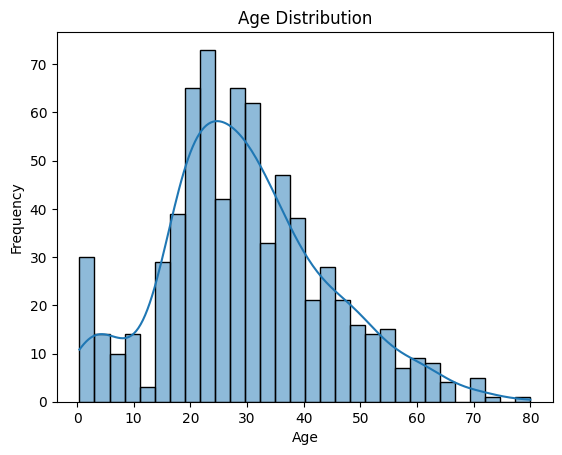

In [9]:
sns.histplot(df['age'], bins=30, kde=True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

i. Display the number of passengers in different classes (pclass).

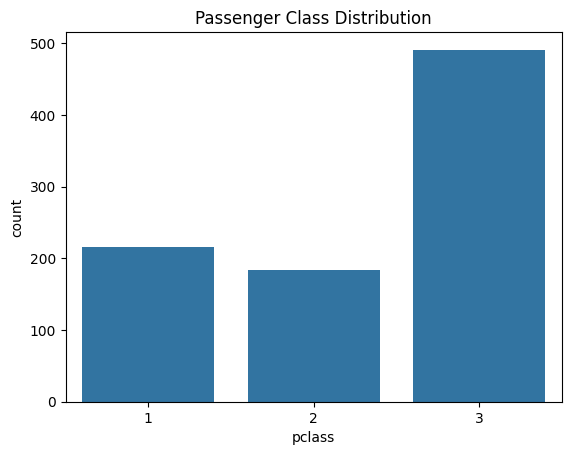

In [10]:
sns.countplot(x='pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

j. Show the distribution of fares paid (fare).

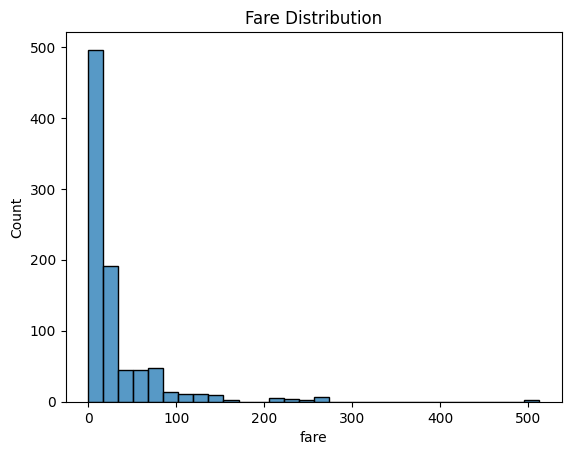

In [11]:
sns.histplot(df['fare'], bins=30)
plt.title("Fare Distribution")
plt.show()

 k. Compare age distributions across different passenger classes (pclass).

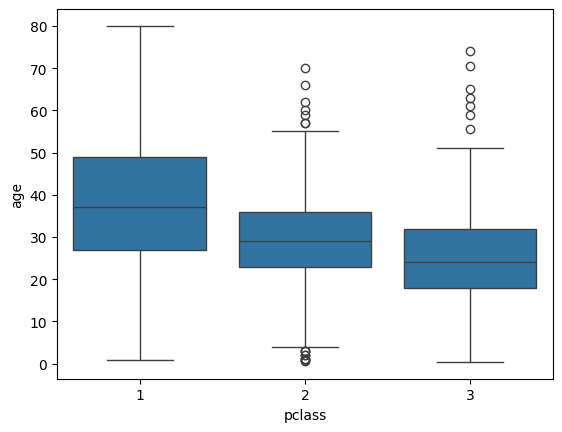

In [12]:
sns.boxplot(x='pclass', y='age', data=df)
plt.show()

l. Show survival status grouped by gender (sex).

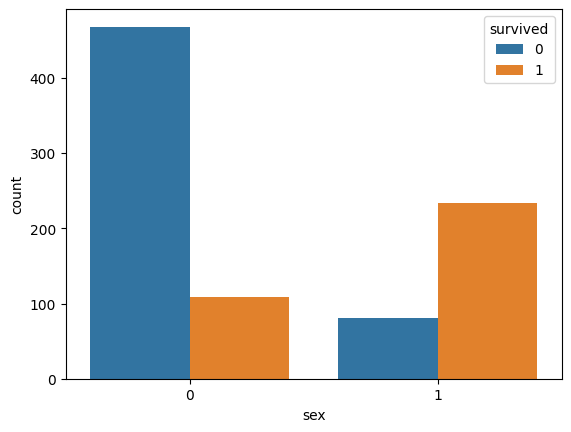

In [13]:
sns.countplot(x='sex', hue='survived', data=df)
plt.show()

m. Show survival status grouped by passenger class (pclass).

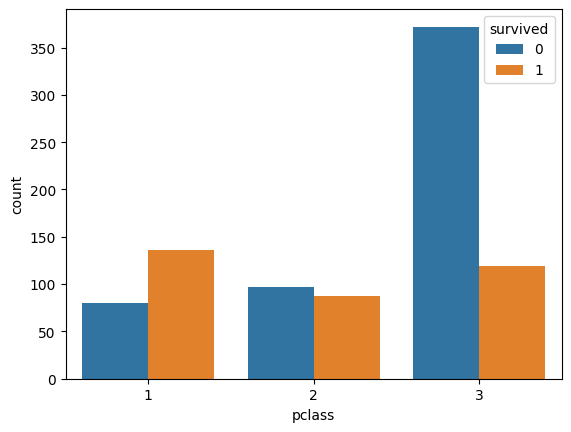

In [14]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.show()

n. Compare the age distribution of survivors and non-survivors.

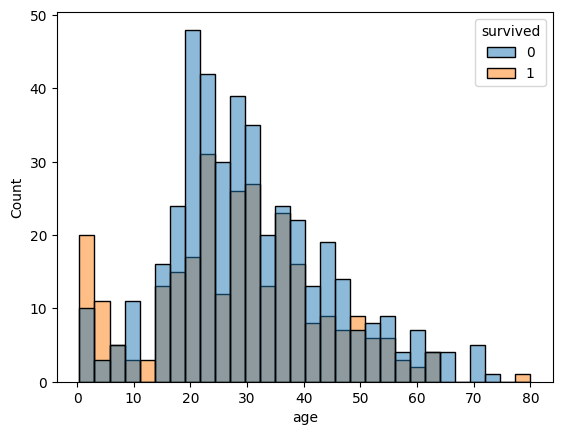

In [15]:
sns.histplot(data=df, x='age', hue='survived', bins=30)
plt.show()

o. Split the dataset into training (80%) and testing (20%) sets.

In [21]:
X = df[['pclass','sex','age','fare']]
y = df['survived']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
display(x_train,y_train,x_test,y_test)

,pclass,sex,age,fare
331,1,0,45.500000,28.5000
733,2,0,23.000000,13.0000
382,3,0,32.000000,7.9250
704,3,0,26.000000,7.8542
813,3,1,6.000000,31.2750
...,...,...,...,...
106,3,1,21.000000,7.6500
270,1,0,29.699118,31.0000
860,3,0,41.000000,14.1083
435,1,1,14.000000,120.0000


,survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


,pclass,sex,age,fare
709,3,0,29.699118,15.2458
439,2,0,31.000000,10.5000
840,3,0,20.000000,7.9250
720,2,1,6.000000,33.0000
39,3,1,14.000000,11.2417
...,...,...,...,...
433,3,0,17.000000,7.1250
773,3,0,29.699118,7.2250
25,3,1,38.000000,31.3875
84,2,1,17.000000,10.5000


,survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


p. Choose two machine learning algorithms to train a classification model.

In [22]:
model1 = LogisticRegression()
model1.fit(x_train,y_train)
y_pred1 = model1.predict(x_test)

In [23]:
model2 = DecisionTreeClassifier()
model2.fit(x_train, y_train)
y_pred2 = model2.predict(x_test)

q. Evaluate the model using the confusion matrix.

In [30]:
print("Decision Tree:", confusion_matrix(y_test, y_pred2))
print("Logistic Regression:", confusion_matrix(y_test, y_pred1))

Decision Tree: [[82 23]
 [21 53]]
Logistic Regression: [[89 16]
 [20 54]]


r. Select age, fare, and class as clustering features

In [25]:
X_cluster = df[['age','fare','pclass']]

s. Scale the data for better clustering performance.

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

t. Apply K-Means clustering
• Experiment with different values of k (number of clusters).
• Use the Elbow Method to determine the optimal k.

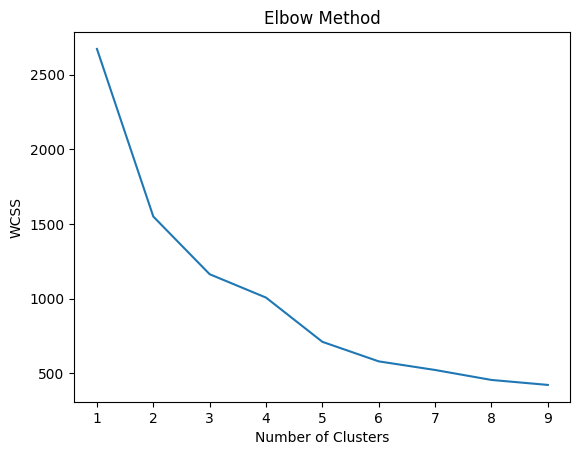

In [27]:
wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

u. Visualize the clusters using a scatter plot.

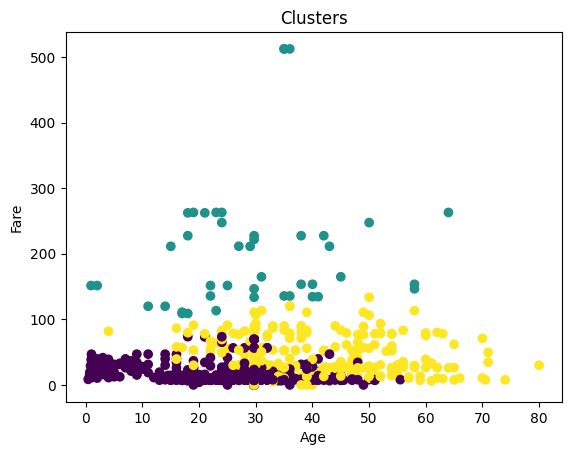

In [29]:
plt.scatter(df['age'], df['fare'], c=df['cluster'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Clusters")
plt.show()